## Student Academic Performance Data Preprocessing Pipeline: A Reproduceable Workflow for Machine Learning Readiness

### Project Objective
This notebook implements a robust, reproducible data preprocessing pipeline designed to transform raw student demographic and behavioral records into a machine-learning-ready state. The primary problem it solves is the presence of noise, inconsistencies, and structural anomalies in educational datasets that typically hinder predictive modeling. The target audience includes machine learning engineers, data scientists, and educational analysts seeking a clean benchmark template for predictive academic analytics. The end goal of this preprocessing workflow is to output a standardized, feature-engineered, and scaled dataset optimized for training high-performance classification models.

### Dataset Summary
The dataset comprises student academic records containing mixed categorical and numerical attributes for 525 students across multiple courses. It contains common data quality challenges; including missing values, incorrect data types, and inconsistent categories, that require systematic cleaning before predictive modeling. Specifically, the dataset contains columns for student ID, age, gender, attendance, study hours, previous GPA, income, course, and final result (the target variable). 

### Tools Used
- Python: The core programming language utilized for end-to-end script execution and pipeline orchestration.
- pandas: Employed for structured data manipulation, handling missing values, and executing tabular transformations.
- NumPy: Used for efficient vectorized numerical operations and mathematical array transformations.
- scikit-learn: Utilized for building encoding pipelines, feature scaling, and data partitioning.
- matplotlib / seaborn: Applied for exploratory data visualization to inspect feature distributions and correlation matrices.

 This notebook is part of the student-performance-data-preprocessing repository. See the README for full project structure and usage instructions.


Author: Adeleke Ibukunoluwa Inioluwa
Date: May 2026

### Environment Setup & Dependencies
To maintain a clean, modular, and professional workflow, all necessary libraries are imported upfront in a single cell. Centralizing imports improves code readability, prevents circular dependency issues, and ensures that all required dependencies are explicitly declared before execution begins.

In [1]:
# Import required libraries for Core Data Manipulation & Numerical Operations
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Preprocessing & Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Configure visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Load Dataset and Inspect Data Structure and Quality
Before performing any data cleaning or transformation, it is essential to load the raw data and conduct an initial structural inspection. This phase helps identify the dataset's dimensions, verify that data types match expectations, and spot early indicators of missing values or anomalies that will need to be addressed in subsequent preprocessing steps.

In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_excel("c:/Users/USER/Documents/Data Preprocessing Project/student_preprocessing_dataset_project.xlsx")

In [3]:
# Preview the first few rows to inspect column names and sample values
df.head()

,Student_ID,Age,Gender,Study_Hours,Attendance,Previous_GPA,Income,Course,Final_Result
0,S1000,22,M,1.12,85.67,1.34,49314,Data Science,Pass
1,S1001,19,M,9.14,96.24,0.70,25456,Economics,Fail
2,S1002,28,Male,7.76,42.20,2.85,39064,Statistics,Pass
3,S1003,Twenty,male,4.19,44.33,3.30,6363,Data Science,Fail
4,S1004,26,Female,4.95,81.29,0.40,21589,Economics,Fail


In [4]:
# Preview the last few rows to verify rows are complete
df.tail()

,Student_ID,Age,Gender,Study_Hours,Attendance,Previous_GPA,Income,Course,Final_Result
520,S1490,23,male,9.14,86.48,1.19,33783,Statistics,Pass
521,S1491,28,male,6.26,97.57,0.42,43078,Data Science,Pass
522,S1280,19,F,1.37,86.15,2.41,9213,Economics,Pass
523,S1356,17,male,1.77,59.48,3.42,24167,Data Science,Pass
524,S1076,19,M,3.34,42.31,1.21,35154,Economics,Fail


In [5]:
# confirm dataset size, it shows number of rows and columns
df.shape

(525, 9)

In [6]:
# Check the structural overview, non-null counts, and data types of each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Student_ID    525 non-null    str    
 1   Age           525 non-null    object 
 2   Gender        525 non-null    str    
 3   Study_Hours   524 non-null    float64
 4   Attendance    524 non-null    float64
 5   Previous_GPA  525 non-null    float64
 6   Income        525 non-null    int64  
 7   Course        525 non-null    str    
 8   Final_Result  525 non-null    str    
dtypes: float64(3), int64(1), object(1), str(4)
memory usage: 48.7+ KB


In [7]:
# Generate a statistical summary of the numerical features
df.describe()

,Study_Hours,Attendance,Previous_GPA,Income
count,524.000000,524.000000,525.000000,525.000000
mean,4.988989,70.310515,1.996552,28543.893333
std,2.955576,17.438162,1.153868,12362.821783
min,0.110000,40.560000,0.000000,5619.000000
25%,2.370000,54.240000,1.110000,18050.000000
50%,5.190000,71.140000,1.990000,28749.000000
75%,7.680000,85.867500,2.990000,38767.000000
max,9.980000,99.960000,3.990000,49814.000000


### Data Quality Assessment & Anomaly Detection
Before executing any cleaning transformations, we must systematically audit the dataset to uncover structural flaws, anomalies, and quality issues. This phase covers a comprehensive scan for missing values, duplicate records, incorrect data types, inconsistent categorical labeling, statistical outliers, and class imbalance. Identifying these issues upfront ensures our preprocessing steps are targeted, transparent, and mathematically sound.

### Missing Values Audit
Missing data can distort statistical analyses and break machine learning model training loops. In this subsection, we quantify the presence of missing values across all columns to determine whether to apply imputation or drop affected records.

In [25]:
# Calculate both the absolute count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)

# Combine into a clean summary DataFrame
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage
})

# Filter to show only columns with missing data and sort by highest percentage first
missing_summary = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

# Display the missing values report
display(missing_summary)

,Missing Count,Missing Percentage (%)
Study_Hours,1,0.19
Attendance,1,0.19


### Duplicate Records Audit
Exact duplicate rows introduce artificial data leakage and bias into machine learning pipelines. If identical student records exist in both the training and testing sets after splitting, the model can artificially memorize examples rather than learn general patterns, leading to inflated and unreliable performance metrics. Running this audit ensures our records represent independent observations.

In [9]:
# Calculate total duplicate count and the percentage of the dataset they represent
total_rows = len(df)
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / total_rows) * 100

print(f"Total number of duplicate rows: {duplicate_count}")
print(f"Percentage of dataset represented by duplicates: {duplicate_percentage:.2f}%")

# Display the actual duplicate rows for visual inspection
if duplicate_count > 0:
    display(df[df.duplicated(keep=False)])
else:
    print("No duplicate rows found in the dataset.")

Total number of duplicate rows: 25
Percentage of dataset represented by duplicates: 4.76%


,Student_ID,Age,Gender,Study_Hours,Attendance,Previous_GPA,Income,Course,Final_Result
9,S1009,25,Female,1.12,52.94,3.00,11474,Statistics,Pass
30,S1030,20,M,7.71,64.41,1.22,17265,data science,Pass
68,S1068,27,F,6.24,90.65,3.49,38650,Statistics,Pass
73,S1073,25,M,7.99,76.43,0.97,20193,Data Science,Pass
76,S1076,19,M,3.34,42.31,1.21,35154,Economics,Fail
84,S1084,Twenty,M,7.60,76.10,2.67,44874,Data Science,Pass
104,S1104,17,M,7.45,78.63,3.52,6757,Data Science,Fail
124,S1124,20,F,0.42,93.05,3.80,25954,Economics,Fail
155,S1155,25,Female,2.50,81.55,1.59,5680,Economics,Fail
194,S1194,Twenty,M,7.89,97.57,3.77,34566,Economics,Pass


### Data Types and Inconsistencies Audit
Algorithms and preprocessing functions rely heavily on underlying data types to execute correctly. Numerical features stored incorrectly as text strings (objects) will fail during mathematical operations, scaling, or model training. This inspection guarantees that continuous metrics, categorical variables, and identifiers are properly cast so they interact seamlessly with pandas and scikit-learn functions. Specifically, we are looking for numeric columns mistakenly formatted as object types, in this case, the Age column.

In [10]:
# Explicitly display data types for every column
print("\n--- Column Data Types ---")
display(df.dtypes)

# Inspect unique values for 'age' to check if it's stored correctly as numeric or trapped as text
print("\n--- Unique Values Check for 'Age' ---")
df["Age"].unique()

# Isolate and count non-numeric or text-based entries in the 'age' column
# This converts entries to strings and checks for non-digit characters (ignoring missing values/NaN)
non_numeric_Age_count = df['Age'].astype(str).str.contains(r'[^0-9\.]', regex=True).sum()

print(f"Total number of non-numeric entries in the 'Age' column: {non_numeric_Age_count}")

# Display the specific rows containing non-numeric age values for inspection
if non_numeric_Age_count > 0:
    display(df[df['Age'].astype(str).str.contains(r'[^0-9\.]', regex=True)])
else:
    print("All entries in the 'Age' column are numeric.")


--- Column Data Types ---


Student_ID          str
Age              object
Gender              str
Study_Hours     float64
Attendance      float64
Previous_GPA    float64
Income            int64
Course              str
Final_Result        str
dtype: object


--- Unique Values Check for 'Age' ---
Total number of non-numeric entries in the 'Age' column: 67


,Student_ID,Age,Gender,Study_Hours,Attendance,Previous_GPA,Income,Course,Final_Result
3,S1003,Twenty,male,4.19,44.33,3.30,6363,Data Science,Fail
28,S1028,Nineteen,Male,4.46,63.67,2.78,29087,Statistics,Fail
41,S1041,Twenty,M,2.58,97.32,3.63,23793,Statistics,Fail
43,S1043,Nineteen,Female,1.79,56.18,2.24,12214,Economics,Fail
46,S1046,Nineteen,Female,5.71,83.84,1.84,13016,Economics,Pass
...,...,...,...,...,...,...,...,...,...
495,S1495,Twenty,M,5.94,54.02,1.44,35099,Economics,Pass
511,S1194,Twenty,M,7.89,97.57,3.77,34566,Economics,Pass
513,S1084,Twenty,M,7.60,76.10,2.67,44874,Data Science,Pass
514,S1371,Nineteen,M,3.19,90.45,0.54,31672,data science,Fail


### Inconsistent Category Audit
Categorical variables frequently suffer from human data-entry errors, such as trailing whitespaces, mixed casing, or spelling variations (e.g., "Pass", "pass", and "Pass " treated as three separate classes). Left uncorrected, these anomalies inflate dimensionality, create redundant features during one-hot encoding, and corrupt categorical groupings. This audit isolates unique category strings to verify uniformity across specific qualitative columns. Specifically, we will be inspecting the unique values for gender, course, and final result.

In [11]:
# Inspect unique values and frequencies for categorical columns to catch spelling or casing inconsistencies
target_categorical_cols = ['Gender', 'Course', 'Final_Result']

for col in target_categorical_cols:
    if col in df.columns:
        print(f"--- Unique values and counts for '{col}' ---")
        display(df[col].value_counts(dropna=False))
    else:
        print(f"Column '{col}' not found in DataFrame.\n")

--- Unique values and counts for 'Gender' ---


Gender
M         123
Female    116
Male      101
F          95
male       90
Name: count, dtype: int64

--- Unique values and counts for 'Course' ---


Course
Statistics      113
data science    110
Economics       102
Economics       101
Data Science     99
Name: count, dtype: int64

--- Unique values and counts for 'Final_Result' ---


Final_Result
Fail    265
Pass    260
Name: count, dtype: int64

### Outlier Detection
Extreme numerical values—whether due to data-entry errors or genuine anomalies—can disproportionately skew descriptive statistics, shift means, and distort variance. Algorithms sensitive to feature scale and distance metrics can be severely disrupted by unmanaged outliers. To address this, we utilize the Interquartile Range (IQR) method, which calculates the range between the 75th and 25th percentiles to establish robust statistical boundaries. IQR is particularly appropriate for this student performance dataset because it is non-parametric, meaning it is less sensitive to skewed distributions than mean-and-standard-deviation methods. We will be applying this outlier audit to continuous numerical columns such as study hours, previous GPA, and income.

In [12]:
# Define a function to calculate IQR boundaries and isolate outliers for specific numerical columns
def detect_outliers_IQR(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"Feature: {column}")
    print(f"  Q1 (25th): {Q1} | Q3 (75th): {Q3} | IQR: {IQR}")
    print(f"  Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")
    
    # Filter and return rows that fall outside the bounds
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"  Outliers Detected: {len(outliers)}\n")
    return outliers

# Apply the IQR outlier detection across target numerical features
numerical_features = ['Attendance', 'Study_Hours', 'Previous_GPA', 'Income']

for col in numerical_features:
    if col in df.columns:
        outlier_df = detect_outliers_IQR(df, col)
        if not outlier_df.empty:
            display(outlier_df.head()) # Preview sample outliers for the column
    else:
        print(f"Column '{col}' not found in DataFrame.\n")

Feature: Attendance
  Q1 (25th): 54.24 | Q3 (75th): 85.8675 | IQR: 31.627500000000005
  Lower Bound: 6.80 | Upper Bound: 133.31
  Outliers Detected: 0

Feature: Study_Hours
  Q1 (25th): 2.37 | Q3 (75th): 7.68 | IQR: 5.31
  Lower Bound: -5.59 | Upper Bound: 15.64
  Outliers Detected: 0

Feature: Previous_GPA
  Q1 (25th): 1.11 | Q3 (75th): 2.99 | IQR: 1.8800000000000001
  Lower Bound: -1.71 | Upper Bound: 5.81
  Outliers Detected: 0

Feature: Income
  Q1 (25th): 18050.0 | Q3 (75th): 38767.0 | IQR: 20717.0
  Lower Bound: -13025.50 | Upper Bound: 69842.50
  Outliers Detected: 0



### Class Imbalance Audit
For binary classification problems like predicting whether a student will pass or fail, a severe distribution imbalance can heavily compromise model reliability. If the dataset contains an overwhelming majority of one class (e.g.predominantly passing students), an unmanaged model can achieve high nominal accuracy simply by predicting the majority class every time, while completely failing to identify the minority class. To determine whether resampling techniques like SMOTE (Synthetic Minority Over-sampling Technique) are necessary, we establish a standard evaluation threshold: if the minority class represents less than 20% of the total dataset, the class distribution is considered imbalanced, and corrective intervention should be applied prior to training.

--- Class Imbalance Summary Table ---


,Class Count,Percentage (%)
Final_Result,,
Fail,265,50.48
Pass,260,49.52



Evaluation Check:
The minority class is 'Pass', representing 49.52% of the dataset.
Result: Class distribution is relatively balanced (>= 20%).


C:\Users\USER\AppData\Local\Temp\ipykernel_12700\978826257.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[target_col], palette="Set2")


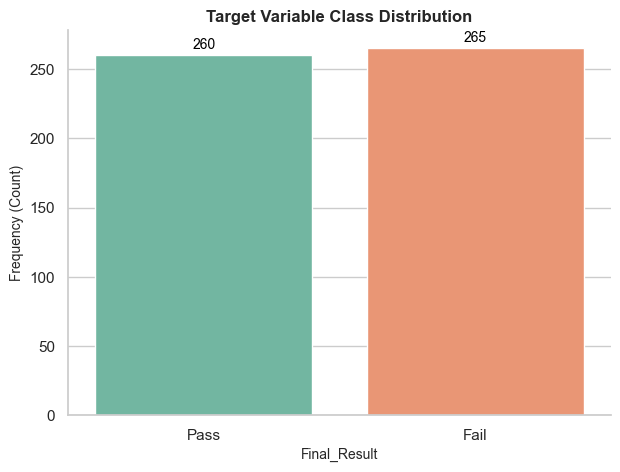

In [13]:
# Analyze the class distribution of the target variable ('final result')
target_col = 'Final_Result'

if target_col in df.columns:
    # Calculate absolute counts and percentages
    class_counts = df[target_col].value_counts()
    class_percentages = (df[target_col].value_counts(normalize=True) * 100).round(2)
    
    class_summary = pd.DataFrame({
        'Class Count': class_counts,
        'Percentage (%)': class_percentages
    })
    
    print("--- Class Imbalance Summary Table ---")
    display(class_summary)
    
    # Check against the 20% minority threshold
    min_class_percentage = class_percentages.min()
    min_class_name = class_percentages.idxmin()
    
    print(f"\nEvaluation Check:")
    print(f"The minority class is '{min_class_name}', representing {min_class_percentage}% of the dataset.")
    if min_class_percentage < 20:
        print("Result: Severe class imbalance detected (< 20%). Resampling techniques (such as SMOTE) are recommended.")
    else:
        print("Result: Class distribution is relatively balanced (>= 20%).")
        
    # Visualize class distribution with data labels on top of bars
    plt.figure(figsize=(7, 5))
    ax = sns.countplot(x=df[target_col], palette="Set2")
    plt.title("Target Variable Class Distribution", fontsize=12, fontweight='bold')
    plt.xlabel(target_col, fontsize=10)
    plt.ylabel("Frequency (Count)", fontsize=10)
    
    # Add count labels on top of each bar for immediate visual readability
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')
                    
    sns.despine()
    plt.show()
else:
    print(f"Target column '{target_col}' not found in DataFrame.")

### Data Cleaning and Preprocessing Pipeline
With our data quality assessment complete, we now execute the preprocessing pipeline to systematically resolve every identified anomaly. Each transformation step is designed to make the dataset robust, cleanly structured, and fully optimized for machine learning algorithms.

In [14]:
# Ensure working on a copy to preserve the raw dataset
df_clean = df.copy()

### Dropping Unnecessary Identifiers (student_id)
Unique identifier columns like student_id contain arbitrary reference numbers that hold no mathematical or predictive value for machine learning algorithms. Leaving them in the feature matrix can cause models to treat them as numerical weights or overfit to noise, so we drop them early.

In [15]:
# Drop columns that do not contribute predictive value to machine learning models
drop_cols = ['Student_ID']

for col in drop_cols:
    if col in df_clean.columns:
        df_clean = df_clean.drop(columns=[col])
        print(f"Dropped redundant column: '{col}'")
    else:
        print(f"Column '{col}' not found.")

Dropped redundant column: 'Student_ID'


### Removing Duplicate Records
Exact duplicate rows introduce artificial data leakage and bias between the training and testing sets. Removing them ensures that every observation in our model is entirely independent, allowing the algorithm to learn genuine general patterns rather than memorizing repeated entries.

In [16]:
# Drop exact duplicate rows and track the count removed
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_removed = initial_rows - len(df_clean)

print(f"Successfully removed {duplicates_removed} duplicate row(s).")
print(f"Current dataset shape: {df_clean.shape}")

Successfully removed 25 duplicate row(s).
Current dataset shape: (500, 8)


### Imputing Missing Values
Missing data points can cause errors or unexpected behavior during model training. By filling missing numerical features with the column median (which is robust against extreme outliers), we preserve dataset size without distorting the underlying distributions.

In [17]:
# Impute missing values using column-specific median and mode assignments
# Numerical columns imputation using explicit column assignment
numerical_cols_to_impute = df_clean.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols_to_impute:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values successfully imputed.")
print(df_clean.isnull().sum().sum(), "total missing values remaining.")

Missing values successfully imputed.
0 total missing values remaining.


### Fixing the Age Data Type
Data entry errors often trap numbers inside text strings—such as spelled-out words like "Nineteen" or "Twenty". We explicitly map these text variants to their integer equivalents and cast the entire column to a numeric type, ensuring it can be processed safely during scaling and modeling.

In [18]:
# Replace text-based age entries and convert column datatype to integer
df_clean["Age"] = df_clean["Age"].replace({"Twenty": 20, "Nineteen": 19}).astype(int)

print("Data type for 'Age' successfully corrected.")
print(df_clean["Age"].dtype)

Data type for 'Age' successfully corrected.
int64


### Standardizing Inconsistent Categories
Qualitative columns frequently suffer from formatting discrepancies like trailing whitespaces, mixed casing, or spelling variations (e.g., "Pass", "pass", "Pass "). Standardizing strings ensures uniformity, preventing redundant classes or inflated dimensionality during one-hot encoding.

In [19]:
# Standardize text formatting: strip whitespaces and convert to lowercase title case for uniformity
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

# Handle specific abbreviations in the 'gender' column (e.g., 'M' to 'Male', 'F' to 'Female')
if 'Gender' in df_clean.columns:
    df_clean['Gender'] = df_clean['Gender'].replace({'M': 'Male', 'F': 'Female'})

print("Categorical strings successfully standardized across columns:", list(cat_cols))

# Verification block: Print unique values for Gender and Course to confirm standardization
print("\n--- Categorical Standardization Verification ---")
if 'Gender' in df_clean.columns:
    print(f"Gender unique values: {df_clean['Gender'].unique()}")
if 'Course' in df_clean.columns:
    print(f"Course unique values: {df_clean['Course'].unique()}")

Categorical strings successfully standardized across columns: ['Gender', 'Course', 'Final_Result']

--- Categorical Standardization Verification ---
Gender unique values: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
Course unique values: <ArrowStringArray>
['Data Science', 'Economics', 'Statistics']
Length: 3, dtype: str


C:\Users\USER\AppData\Local\Temp\ipykernel_12700\2646284252.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns


### Encode Categorical Variables
Before feeding features into machine learning algorithms, all qualitative text data must be transformed into quantitative representations. Different categorical variables require different encoding strategies based on their role and nature within the dataset:

- Explicit Target Mapping (.map()): For our binary target variable (Final_Result), we avoid automated tools like LabelEncoder (which assigns numerical values alphabetically, risking arbitrary and uncontrolled mapping like Pass=0 and Fail=1). Instead, we use an explicit .map({'Pass': 1, 'Fail': 0}) dictionary mapping to retain absolute control over the numeric assignment.

- One-Hot Encoding (pd.get_dummies()): For nominal categorical features like Gender and Course, categories have no inherent mathematical ranking or ordinal relationship. One-hot encoding creates independent binary (0 or 1) indicator columns for each category.

Avoiding the Dummy Variable Trap (drop_first=True): When generating one-hot columns, categories are perfectly collinear (e.g., if a row is not Male, it must be Female). Setting drop_first=True drops the first encoded dummy column, preventing multicollinearity which can destabilize linear and distance-based models.

In [20]:
# Part 1: Explicit mapping for the target variable 'Final_Result' (Pass -> 1, Fail -> 0)
# This guarantees precise control over numerical encoding, avoiding alphabetical ambiguity
target_col = 'Final_Result'

if target_col in df_clean.columns:
    df_clean[target_col] = df_clean[target_col].map({'Pass': 1, 'Fail': 0})
    print(f"Target column '{target_col}' successfully mapped: Pass -> 1, Fail -> 0")
else:
    print(f"Target column '{target_col}' not found.")

# Part 2: One-Hot Encoding for remaining nominal categorical features ('Gender', 'Course')
nominal_cols = ['Gender', 'Course']

# Filter columns that actually exist in the dataframe
existing_nominal_cols = [col for col in nominal_cols if col in df_clean.columns]

if existing_nominal_cols:
    df_encoded = pd.get_dummies(df_clean, columns=existing_nominal_cols, drop_first=True)
    print(f"Nominal categorical columns successfully one-hot encoded: {existing_nominal_cols}")
else:
    df_encoded = df_clean.copy()
    print("No nominal categorical columns found for one-hot encoding.")

print(f"Final encoded dataset shape: {df_encoded.shape}")

Target column 'Final_Result' successfully mapped: Pass -> 1, Fail -> 0
Nominal categorical columns successfully one-hot encoded: ['Gender', 'Course']
Final encoded dataset shape: (500, 9)


### Train/Test Splitting
To evaluate how well our model generalizes to unseen data, we partition the dataset into a training set (to fit the algorithms) and a testing set (to simulate real-world evaluation). We also apply stratification on the target variable to maintain the exact class balance across both subsets.

Preventing Data Leakage: A critical rule in machine learning pipelines is that the test set must remain entirely untouched and unknown during the training preparation. If we were to fit our feature scaler or imputation parameters on the entire dataset prior to splitting, statistical information (such as the mean and standard deviation) from the test set would leak into the training process. This "data leakage" artificially inflates evaluation metrics and gives a false sense of model performance. By performing the train/test split first, we ensure the scaler is fitted exclusively on X_train and merely applied to X_test, preserving a strict boundary between training knowledge and real-world evaluation.

In [21]:
# Separate features (X) and target variable (y) directly from the encoded DataFrame
target_column = 'Final_Result'

y = df_encoded[target_column]
X = df_encoded.drop(columns=[target_column])

# Split data into 80% training set and 20% testing set with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set dimensions: {X_train.shape}")
print(f"Testing set dimensions: {X_test.shape}")

Training set dimensions: (400, 8)
Testing set dimensions: (100, 8)


### Feature Scaling
Why we do this: Features with larger numeric ranges (e.g., income in thousands) can disproportionately dominate distance-based and gradient-based algorithms compared to smaller features (e.g., study hours). Using StandardScaler standardizes continuous numerical features to a mean of 0 and a standard deviation of 1, ensuring fair and balanced algorithmic weighting.

Excluding Binary Variables: One-hot encoded categorical columns contain only binary flags (0s and 1s). Scaling these features would distort their interpretation as discrete categories, so they are intentionally excluded from the scaling transformation.

In [22]:
# Identify continuous numerical features versus binary one-hot encoded features
# Binary columns typically have unique values of {0, 1} or boolean dtypes
binary_cols = [col for col in X_train.columns if X_train[col].nunique() <= 2]
numerical_cols = [col for col in X_train.columns if col not in binary_cols]

print(f"Numerical features to scale: {numerical_cols}")
print(f"Binary features excluded from scaling: {binary_cols}")

# Initialize StandardScaler
scaler = StandardScaler()

# Fit only on training numerical data to prevent data leakage, then transform both train and test numerical sets
X_train_num_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_num_scaled = scaler.transform(X_test[numerical_cols])

# Convert scaled numerical arrays back to DataFrames
X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns=numerical_cols, index=X_train.index)
X_test_num_scaled = pd.DataFrame(X_test_num_scaled, columns=numerical_cols, index=X_test.index)

# Recombine the scaled numerical features with the unscaled binary features
X_train_scaled = pd.concat([X_train_num_scaled, X_train[binary_cols]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled, X_test[binary_cols]], axis=1)

print("\nFeature scaling successfully completed.")
display(X_train_scaled.head())

Numerical features to scale: ['Age', 'Study_Hours', 'Attendance', 'Previous_GPA', 'Income']
Binary features excluded from scaling: ['Gender_Male', 'Course_Economics', 'Course_Statistics']

Feature scaling successfully completed.


,Age,Study_Hours,Attendance,Previous_GPA,Income,Gender_Male,Course_Economics,Course_Statistics
170,0.225358,0.112604,0.924443,1.406341,1.624817,True,True,False
464,1.224172,-0.827389,0.643075,-0.651007,0.174296,False,False,True
34,-0.274050,-0.532156,-1.388067,0.517148,0.604319,True,True,False
428,-1.522568,-0.566091,-1.503721,-0.511525,0.290667,True,False,False
24,1.224172,0.363721,1.158053,-0.964839,1.620143,True,True,False


### Validating the Cleaned Data

After cleaning and preparing the dataset, it is important to check through the dataset again to ensure all codes for handling issues have run appropriately.


In [26]:
# Comprehensive validation check for the cleaned dataset
print("=== PIPELINE VALIDATION REPORT ===")

# 1. Check shape and missing values
print(f"1. Dataset Shape: {df_clean.shape}")
total_missing = df_clean.isnull().sum().sum()
print(f"2. Total Missing Values: {total_missing}")

# 2. Check duplicate count
duplicates = df_clean.duplicated().sum()
print(f"3. Total Duplicate Rows: {duplicates}")

# 3. Verify 'Age' data type
print(f"4. 'Age' Data Type: {df_clean['Age'].dtype} (Expected: int)")

# 4. Verify categorical standardization (checking unique values for key columns)
print("5. Categorical Standardization Check:")
for col in df_clean.select_dtypes(include=['object', 'category']).columns:
    print(f"   - {col}: {df_clean[col].unique()[:5]}") # Display first 5 unique values

# 5. Verify Train/Test shapes and scaling consistency
print(f"6. X_train_scaled Shape: {X_train_scaled.shape}")
print(f"7. X_test_scaled Shape: {X_test_scaled.shape}")
print(f"   - Scaled Mean (approx 0): {X_train_scaled.mean().mean():.4f}")
print(f"   - Scaled Std Dev (approx 1): {X_train_scaled.std().mean():.4f}")

print("\nValidation Complete: All preprocessing steps executed!")

=== PIPELINE VALIDATION REPORT ===
1. Dataset Shape: (500, 8)
2. Total Missing Values: 0
3. Total Duplicate Rows: 0
4. 'Age' Data Type: int64 (Expected: int)
5. Categorical Standardization Check:
   - Gender: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
   - Course: <ArrowStringArray>
['Data Science', 'Economics', 'Statistics']
Length: 3, dtype: str
6. X_train_scaled Shape: (400, 8)
7. X_test_scaled Shape: (100, 8)
   - Scaled Mean (approx 0): 0.1512
   - Scaled Std Dev (approx 1): 0.7998

Validation Complete: All preprocessing steps executed!


C:\Users\USER\AppData\Local\Temp\ipykernel_12700\489565977.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object', 'category']).columns:


### Exporting the Processed Data
After completing all data cleaning, imputation, transformation, and feature scaling steps, saving the final processed datasets ensures reproducibility and allows for seamless integration into modeling and visualization notebooks.

Why Save as CSV: Comma-Separated Values (CSV) is the universal standard format for tabular data. It is lightweight, universally readable across different programming environments and tools (such as Python, R, Tableau, and Power BI), and ideal for git-tracked repositories.

Why Save as Excel: Exporting an Excel version (.xlsx) provides a convenient format for business stakeholders, non-technical collaborators, or manual spot-checking in spreadsheet software.

In [ ]:
# Export the final processed training and testing sets to CSV and Excel formats
# This ensures processed data is persisted for subsequent modeling workflows and stakeholder sharing

# 1. Export to CSV format
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# 2. Export to Excel format (combining features and target for convenience if needed, or saving individual sets)
# Using ExcelWriter to save multiple sheets into a single workbook for neat organization
with pd.ExcelWriter('../data/processed/processed_student_dataset.xlsx', engine='openpyxl') as writer:
    X_train_scaled.to_excel(writer, sheet_name='X_Train_Scaled', index=False)
    X_test_scaled.to_excel(writer, sheet_name='X_Test_Scaled', index=False)
    y_train.to_excel(writer, sheet_name='y_Train', index=False)
    y_test.to_excel(writer, sheet_name='y_Test', index=False)

print("Datasets successfully exported to both CSV and Excel formats!")

Datasets successfully exported to both CSV and Excel formats!
